[INFO] Exogenous variables per target:
  ron95: ['usdmyr', 'wti', 'ron95_policy']
  ron97: ['usdmyr', 'wti', 'ron97_policy']
  diesel: ['usdmyr', 'wti', 'diesel_policy']
  cpi_transport: ['ron97', 'diesel']
  cpi_headline: ['cpi_transport']
Data shape: (71, 10)
Data start/end: 2020-01-31 00:00:00 → 2025-11-30 00:00:00
Saved alerts:
- ../data/outputs_dashboard/dashboard_alerts_full.csv
- ../data/outputs_dashboard/dashboard_alerts_latest.csv
Saved model health: ../data/outputs_dashboard/dashboard_model_health.csv
[BASELINE] ron95 -> ETS using 'ETS(add,add,None)'
[BASELINE] ron97 -> ARIMAX using 'ARIMAX(1, 1, 1)'
[BASELINE] diesel -> ARIMAX using 'ARIMAX(1, 1, 1)'
[BASELINE] cpi_transport -> ETS using 'ETS(add,add,None)'
[BASELINE] cpi_headline -> ARIMAX using 'ARIMAX(1, 1, 1)'
Saved baseline 6m: ../data/outputs_dashboard/dashboard_baseline_6m.csv
Saved scenarios: ../data/outputs_dashboard/dashboard_scenarios.csv


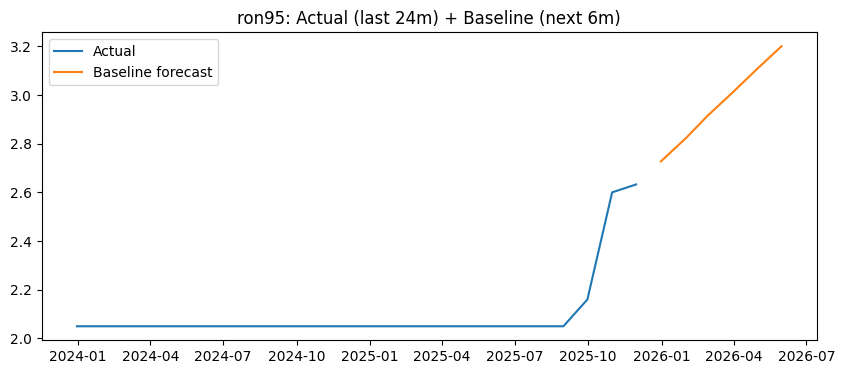

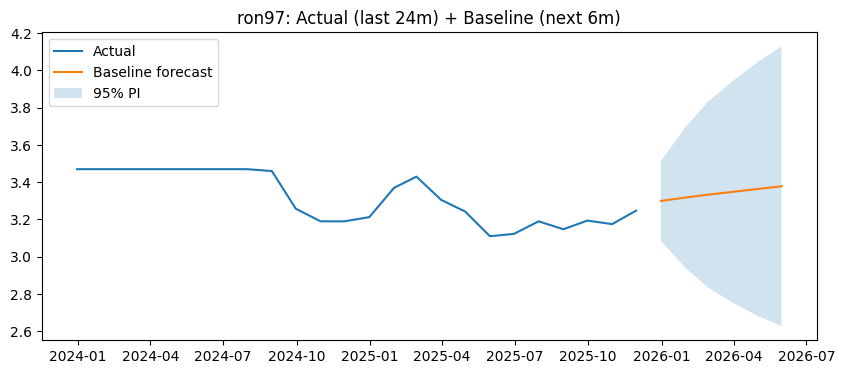

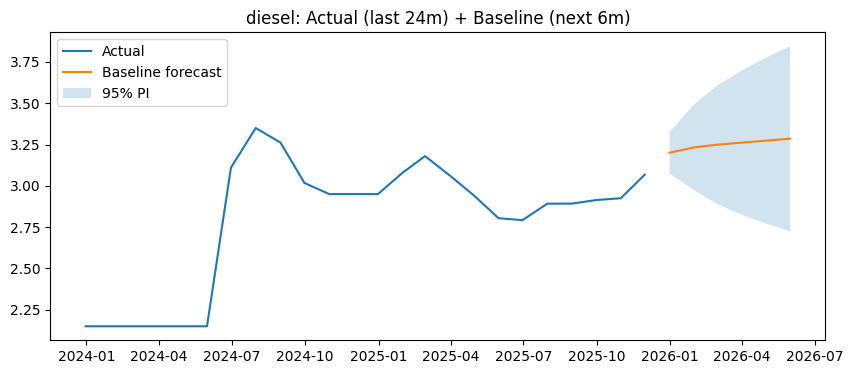

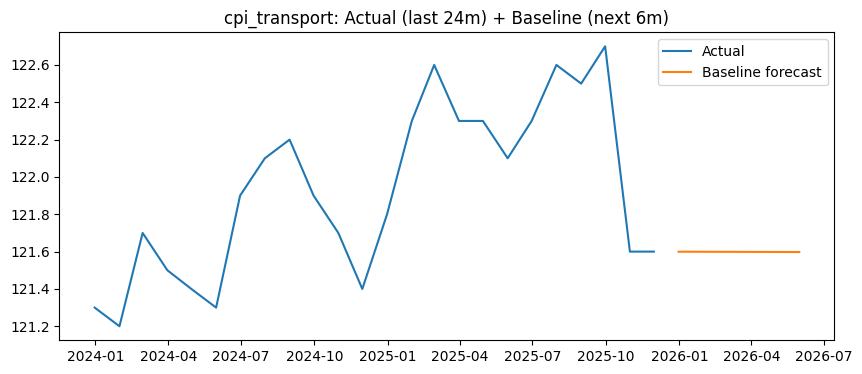

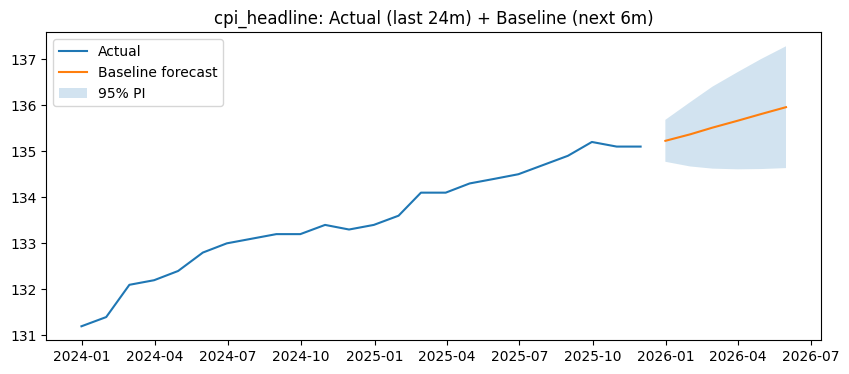

No matching scenario.


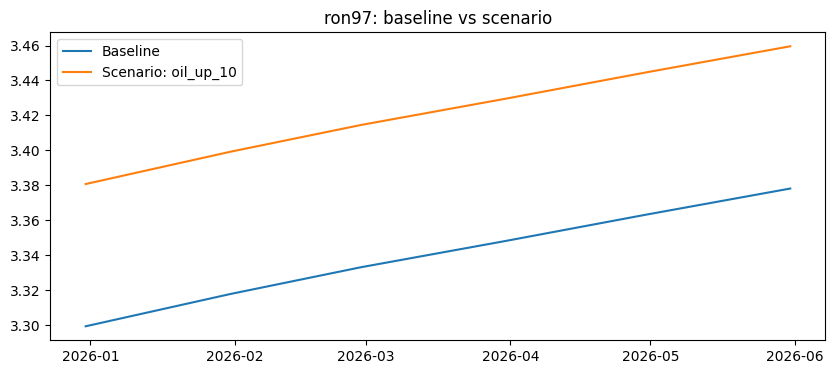

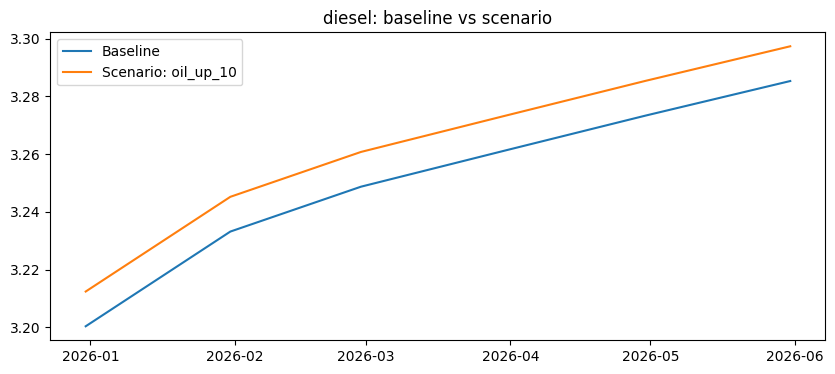

No matching scenario.


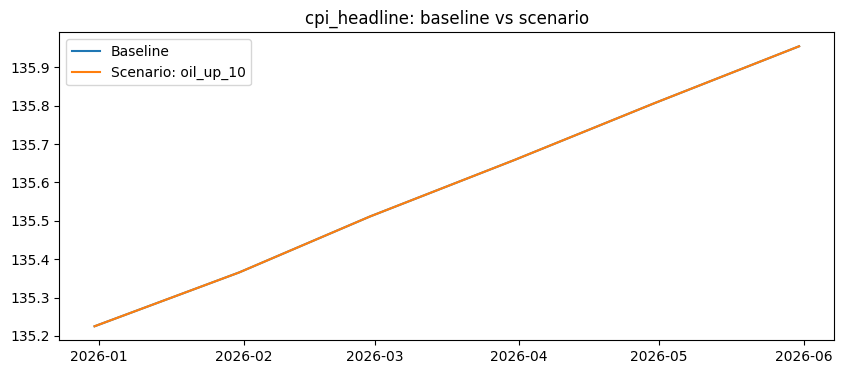

DONE. Files ready for dashboard in: ../data/outputs_dashboard


In [4]:
# Monitoring + Residual Alerts + Scenarios

import warnings
warnings.filterwarnings("ignore")

import re
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from dataclasses import dataclass
from typing import Dict, List, Optional, Tuple

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.exponential_smoothing.ets import ETSModel
from sklearn.metrics import mean_squared_error, mean_absolute_error


# Paths 
DATA_PATH = "../data/processed/passthrough_dataset.csv"
ROLLING_PATH = "../data/outputs/rolling_forecasts_all.csv"
METRICS_PATH = "../data/outputs/forecast_metrics_all.csv"
COVERAGE_PATH = "../data/outputs/forecast_interval_coverage.csv"
BEST_PATH = "../data/outputs/forecast_best_by_rmse.csv"  

OUT_DIR = "../data/outputs_dashboard"

# Project settings
TARGETS = ["ron95", "ron97", "diesel", "cpi_transport", "cpi_headline"]
HORIZON_MAX = 6

# Residual scoring settings
RESID_WINDOW = 24          # rolling window for residual stats (months)
EWMA_ALPHA = 0.2
Z_WARN = 2.5
Z_ALERT = 3.0
DRIFT_THRESH = 2.0         # drift flag using rolling mean shifts


# 1) Load dataset (for refit + future exog construction)
df = pd.read_csv(DATA_PATH, parse_dates=["date"]).set_index("date")
df = df.asfreq("ME")

# Ensure policy dummies exist 
if "ron95_policy" not in df.columns:
    df["ron95_policy"] = (df.index >= "2025-09-01").astype(int)
if "ron97_policy" not in df.columns:
    df["ron97_policy"] = (df.index >= "2025-09-01").astype(int)
if "diesel_policy" not in df.columns:
    # if you had a real diesel policy change date, replace it
    df["diesel_policy"] = (df.index >= "2024-06-01").astype(int)

# Exog mapping consistent with earlier forecasting 
# -----------------------------
# Auto-generated exogenous mapping
# -----------------------------
EXOG_MAP = {
    # Fuel prices: oil + FX + policy
    "ron95": ["usdmyr", OIL_VAR, "ron95_policy"],
    "ron97": ["usdmyr", OIL_VAR, "ron97_policy"],
    "diesel": ["usdmyr", OIL_VAR, "diesel_policy"],

    # CPI transport: fuel-driven
    "cpi_transport": ["ron97", "diesel"],

    # CPI headline: transport-driven
    "cpi_headline": ["cpi_transport"],
}

print("[INFO] Exogenous variables per target:")
for k, v in EXOG_MAP.items():
    print(f"  {k}: {v}")


# Keep only required columns & drop NA
needed_cols = sorted(set(TARGETS + sum(EXOG_MAP.values(), []) + ["wti", "usdmyr"]))
data = df[ [c for c in needed_cols if c in df.columns] ].copy()
data = data.apply(pd.to_numeric, errors="coerce").dropna()

print("Data shape:", data.shape)
print("Data start/end:", data.index.min(), "→", data.index.max())
data.tail()


# 2) Load evaluation outputs (rolling OOS files)

roll = pd.read_csv(ROLLING_PATH, parse_dates=["origin"])
metrics = pd.read_csv(METRICS_PATH)
coverage = pd.read_csv(COVERAGE_PATH) if os.path.exists(COVERAGE_PATH) else pd.DataFrame()
best_by_rmse = pd.read_csv(BEST_PATH) if os.path.exists(BEST_PATH) else pd.DataFrame()

# Derive target_date from origin + horizon (same logic as we used before)
roll = pd.read_csv(ROLLING_PATH, parse_dates=["origin"])
roll["origin"] = pd.to_datetime(roll["origin"])
roll["horizon"] = roll["horizon"].astype(int)

roll["target_date"] = [
    o + pd.offsets.MonthEnd(h - 1)
    for o, h in zip(roll["origin"], roll["horizon"])
]

roll["resid"] = roll["y_true"] - roll["y_pred"]


# 3) Choose FINAL baseline model per target (average RMSE across horizons)

def choose_baseline_models(metrics_df: pd.DataFrame) -> pd.DataFrame:
    m = metrics_df.copy()
    # Average RMSE across horizons per target+model
    avg = (m.groupby(["target", "model"], as_index=False)
            .agg(avg_RMSE=("RMSE", "mean"),
                 avg_MAE=("MAE", "mean"),
                 avg_MAPE=("MAPE_%", "mean"),
                 n=("n_forecasts", "sum")))
    best = (avg.sort_values(["target", "avg_RMSE"])
              .groupby("target", as_index=False).head(1))
    return best.sort_values("target").reset_index(drop=True)

baseline_choice = choose_baseline_models(metrics)
baseline_choice

# 4) Parse model strings 
def parse_model_name(model_str: str) -> Tuple[str, Optional[Tuple[int,int,int]]]:
    s = str(model_str)

    if s.startswith("ARIMAX"):
        # e.g. "ARIMAX(1, 1, 1)" or "ARIMAX(1,1,1)"
        nums = re.findall(r"\d+", s)
        if len(nums) >= 3:
            return "ARIMAX", (int(nums[0]), int(nums[1]), int(nums[2]))
        return "ARIMAX", (1,1,1)

    if s.startswith("ARIMA"):
        nums = re.findall(r"\d+", s)
        if len(nums) >= 3:
            return "ARIMA", (int(nums[0]), int(nums[1]), int(nums[2]))
        return "ARIMA", (1,1,1)

    if s.startswith("ETS"):
        return "ETS", None

    # default fallback
    return "ARIMA", (1,1,1)

# 5) Residual scoring: unexpected deviation + drift + break flags
def add_residual_scores(df_one_model: pd.DataFrame,
                        window: int = RESID_WINDOW,
                        ewma_alpha: float = EWMA_ALPHA) -> pd.DataFrame:
    df = df_one_model.sort_values("target_date").copy()

    df["resid_mean"] = df["resid"].rolling(window).mean()
    df["resid_std"]  = df["resid"].rolling(window).std(ddof=0)

    df["z"] = (df["resid"] - df["resid_mean"]) / (df["resid_std"] + 1e-9)
    df["ewma"] = df["resid"].ewm(alpha=ewma_alpha, adjust=False).mean()

    # spike alerts
    df["alert_spike"] = (df["z"].abs() >= Z_ALERT).astype(int)
    df["warn_spike"]  = ((df["z"].abs() >= Z_WARN) & (df["z"].abs() < Z_ALERT)).astype(int)

    # drift flag: compare rolling mean now vs rolling mean 12 months ago
    df["mean_shift"] = (df["resid_mean"] - df["resid_mean"].shift(12)) / (df["resid_std"] + 1e-9)
    df["alert_drift"] = (df["mean_shift"].abs() >= DRIFT_THRESH).astype(int)

    # simple break flag: big jump in rolling std (variance regime change)
    df["std_shift"] = (df["resid_std"] / (df["resid_std"].shift(12) + 1e-9))
    df["alert_varbreak"] = (df["std_shift"] >= 2.0).astype(int)

    # severity label
    def sev(row):
        if row["alert_spike"] == 1:
            return "ALERT_SPIKE"
        if row["alert_drift"] == 1:
            return "ALERT_DRIFT"
        if row["alert_varbreak"] == 1:
            return "ALERT_VARBREAK"
        if row["warn_spike"] == 1:
            return "WARN_SPIKE"
        return "OK"

    df["severity"] = df.apply(sev, axis=1)
    return df


def build_alerts_from_rolling(roll_df: pd.DataFrame, baseline_choice_df: pd.DataFrame) -> pd.DataFrame:

    out = []
    for _, row in baseline_choice_df.iterrows():
        tgt = row["target"]
        model = row["model"]

        sub = roll_df[(roll_df["target"] == tgt) &
                      (roll_df["model"] == model) &
                      (roll_df["horizon"] == 1)].copy()

        if sub.empty:
            print(f"[WARN] No rolling rows for target={tgt}, model={model}, horizon=1")
            continue

        scored = add_residual_scores(sub)
        out.append(scored)

    if not out:
        return pd.DataFrame()

    alerts = pd.concat(out, ignore_index=True)
    return alerts

alerts_full = build_alerts_from_rolling(roll, baseline_choice)
alerts_full.tail()


# Latest alerts (last available month per target)
alerts_latest = (alerts_full.sort_values("target_date")
                 .groupby("target", as_index=False)
                 .tail(1)
                 .sort_values("target"))

alerts_latest


# Save alerts
alerts_full.to_csv(f"{OUT_DIR}/dashboard_alerts_full.csv", index=False)
alerts_latest.to_csv(f"{OUT_DIR}/dashboard_alerts_latest.csv", index=False)

print("Saved alerts:")
print(f"- {OUT_DIR}/dashboard_alerts_full.csv")
print(f"- {OUT_DIR}/dashboard_alerts_latest.csv")


# 6) Model health monitoring (rolling RMSE/MAE on 12-month window)
def compute_model_health(alerts_scored: pd.DataFrame, window: int = 12) -> pd.DataFrame:
    rows = []
    for tgt, g in alerts_scored.groupby("target"):
        g = g.sort_values("target_date").copy()
        g["abs_err"] = (g["y_true"] - g["y_pred"]).abs()
        g["sq_err"] = (g["y_true"] - g["y_pred"])**2

        g["roll_MAE"] = g["abs_err"].rolling(window).mean()
        g["roll_RMSE"] = np.sqrt(g["sq_err"].rolling(window).mean())
        g["roll_bias"] = (g["y_true"] - g["y_pred"]).rolling(window).mean()

        # interval coverage if present
        has_int = g[["lo95","hi95"]].notna().all(axis=1)
        if has_int.any():
            covered = ((g.loc[has_int, "y_true"] >= g.loc[has_int, "lo95"]) &
                       (g.loc[has_int, "y_true"] <= g.loc[has_int, "hi95"])).astype(int)
            # align coverage series back to all rows
            g["covered"] = np.nan
            g.loc[has_int, "covered"] = covered.values
            g["roll_cov95"] = g["covered"].rolling(window).mean()
        else:
            g["roll_cov95"] = np.nan

        rows.append(g[["target","model","target_date","roll_MAE","roll_RMSE","roll_bias","roll_cov95"]])

    return pd.concat(rows, ignore_index=True)

model_health = compute_model_health(alerts_full, window=12)
model_health.to_csv(f"{OUT_DIR}/dashboard_model_health.csv", index=False)
print(f"Saved model health: {OUT_DIR}/dashboard_model_health.csv")

model_health.tail()


# 7) Refit baseline models on FULL history and create 6-month baseline projection

def fit_arima_full(y: pd.Series, order=(1,1,1)):
    m = SARIMAX(y, order=order, trend="c",
                enforce_stationarity=False, enforce_invertibility=False)
    return m.fit(disp=False)

def fit_arimax_full(y: pd.Series, X: pd.DataFrame, order=(1,1,1)):
    m = SARIMAX(y, exog=X, order=order, trend="c",
                enforce_stationarity=False, enforce_invertibility=False)
    return m.fit(disp=False)

def fit_ets_full(y: pd.Series, error="add", trend="add", seasonal=None, seasonal_periods=None):
    m = ETSModel(y, error=error, trend=trend, seasonal=seasonal, seasonal_periods=seasonal_periods)
    return m.fit(disp=False)

def make_future_index(last_date: pd.Timestamp, steps: int) -> pd.DatetimeIndex:
    # month-end dates
    return pd.date_range(last_date + pd.offsets.MonthEnd(1), periods=steps, freq="ME")

def build_future_exog_baseline(hist: pd.DataFrame,
                               exog_cols: List[str],
                               future_index: pd.DatetimeIndex) -> pd.DataFrame:
    
    Xf = pd.DataFrame(index=future_index)
    for c in exog_cols:
        if c not in hist.columns:
            raise ValueError(f"Missing exog column in data: {c}")

        # dummies: carry last value
        if c.endswith("_policy"):
            Xf[c] = int(hist[c].iloc[-1])
        else:
            Xf[c] = float(hist[c].iloc[-1])
    return Xf

def forecast_with_intervals_sarimax(res, steps: int, exog_future: Optional[pd.DataFrame] = None) -> pd.DataFrame:
    fc = res.get_forecast(steps=steps, exog=exog_future)
    mean = fc.predicted_mean
    ci = fc.conf_int(alpha=0.05)
    out = pd.DataFrame({"yhat": mean.values,
                        "lo95": ci.iloc[:,0].values,
                        "hi95": ci.iloc[:,1].values},
                        index=mean.index)
    return out

def forecast_ets_point(res, steps: int, future_index: pd.DatetimeIndex) -> pd.DataFrame:
    pred = res.forecast(steps)
    pred.index = future_index
    return pd.DataFrame({"yhat": pred.values}, index=future_index)

# build baseline forecasts for ALL targets using their chosen baseline model.
baseline_forecasts = []

last_date = data.index.max()
future_index = make_future_index(last_date, HORIZON_MAX)

# IMPORTANT: cpi_headline depends on cpi_transport exog, which we may forecast first
# We'll compute in a dependency-safe order.
ORDER_CHAIN = ["ron95", "ron97", "diesel", "cpi_transport", "cpi_headline"]

# store future paths for chaining
future_paths = {}

for tgt in ORDER_CHAIN:
    choice_row = baseline_choice[baseline_choice["target"] == tgt].iloc[0]
    model_str = choice_row["model"]
    model_type, order = parse_model_name(model_str)

    y_hist = data[tgt].copy()

    # build exog for model if needed
    exog_cols = EXOG_MAP.get(tgt, [])
    X_hist = data[exog_cols].copy() if exog_cols else None

    # For chained exog: if exog includes "cpi_transport", substitute with its forecast path once available
    # This impacts CPI headline baseline forecast.
    if X_hist is not None and "cpi_transport" in X_hist.columns and "cpi_transport" in future_paths:
        pass  

    print(f"[BASELINE] {tgt} -> {model_type} using '{model_str}'")

    if model_type == "ETS":
        # Fit ETS
        ets_res = fit_ets_full(y_hist, error="add", trend="add", seasonal=None, seasonal_periods=None)
        fc = forecast_ets_point(ets_res, HORIZON_MAX, future_index)

        fc["target"] = tgt
        fc["model"] = model_str
        fc["scenario"] = "baseline"

        baseline_forecasts.append(fc.reset_index().rename(columns={"index":"date"}))
        future_paths[tgt] = fc["yhat"].copy()

    elif model_type == "ARIMA":
        arima_res = fit_arima_full(y_hist, order=order)
        fc = forecast_with_intervals_sarimax(arima_res, HORIZON_MAX, exog_future=None)

        fc["target"] = tgt
        fc["model"] = model_str
        fc["scenario"] = "baseline"

        baseline_forecasts.append(fc.reset_index().rename(columns={"index":"date"}))
        future_paths[tgt] = fc["yhat"].copy()

    elif model_type == "ARIMAX":
        # Build baseline future exog
        X_future = build_future_exog_baseline(data, exog_cols, future_index)

        # chain: CPI headline uses cpi_transport
        if "cpi_transport" in exog_cols and "cpi_transport" in future_paths:
            X_future["cpi_transport"] = future_paths["cpi_transport"].values

        arimax_res = fit_arimax_full(y_hist, X_hist, order=order)
        fc = forecast_with_intervals_sarimax(arimax_res, HORIZON_MAX, exog_future=X_future)

        fc["target"] = tgt
        fc["model"] = model_str
        fc["scenario"] = "baseline"

        baseline_forecasts.append(fc.reset_index().rename(columns={"index":"date"}))
        future_paths[tgt] = fc["yhat"].copy()

    else:
        raise ValueError(f"Unknown model_type: {model_type}")

baseline_6m = pd.concat(baseline_forecasts, ignore_index=True)
baseline_6m.to_csv(f"{OUT_DIR}/dashboard_baseline_6m.csv", index=False)
print(f"Saved baseline 6m: {OUT_DIR}/dashboard_baseline_6m.csv")

baseline_6m.head(10)


# 8) Scenario simulation (for ARIMAX targets)
def apply_shocks_to_exog(X_future: pd.DataFrame, shock_rules: Dict[str, float]) -> pd.DataFrame:
    
    Xs = X_future.copy()
    for k, v in shock_rules.items():
        if k not in Xs.columns:
            continue
        if k.endswith("_policy"):
            Xs[k] = int(v)
        else:
            Xs[k] = Xs[k] * (1.0 + float(v))
    return Xs

def simulate_arimax_scenario(
    target: str,
    model_order: Tuple[int,int,int],
    exog_cols: List[str],
    shock_rules: Dict[str, float],
    horizon: int = 6
) -> pd.DataFrame:
    """
    Fit ARIMAX on full history, then compare baseline vs scenario forecast over horizon.
    """
    y_hist = data[target].copy()
    X_hist = data[exog_cols].copy()

    last_date = data.index.max()
    future_index = make_future_index(last_date, horizon)

    X_base = build_future_exog_baseline(data, exog_cols, future_index)

    # chain: headline uses cpi_transport baseline path as exog
    if "cpi_transport" in exog_cols:
        # Ensure baseline cpi_transport path (already computed above)
        if "cpi_transport" not in future_paths:
            raise ValueError("Missing baseline future path for cpi_transport.")
        X_base["cpi_transport"] = future_paths["cpi_transport"].iloc[:horizon].values

    X_scn = apply_shocks_to_exog(X_base, shock_rules)

    res_fit = fit_arimax_full(y_hist, X_hist, order=model_order)

    fc_base = res_fit.get_forecast(steps=horizon, exog=X_base)
    fc_scn  = res_fit.get_forecast(steps=horizon, exog=X_scn)

    out = pd.DataFrame(index=future_index)
    out["yhat_base"] = fc_base.predicted_mean.values
    out["yhat_scn"]  = fc_scn.predicted_mean.values
    out["delta"] = out["yhat_scn"] - out["yhat_base"]

    # intervals (baseline only, scenario could be added too but keep it clean)
    ci = fc_base.conf_int(alpha=0.05)
    out["lo95_base"] = ci.iloc[:,0].values
    out["hi95_base"] = ci.iloc[:,1].values

    out = out.reset_index().rename(columns={"index":"date"})
    out["target"] = target
    out["shock_rules"] = str(shock_rules)
    return out

# Define a small set of standard scenarios 
SCENARIOS = [
    ("oil_up_10", {"wti": 0.10}),
    ("fx_up_05", {"usdmyr": 0.05}),
    ("oil_up_10_fx_up_05", {"wti": 0.10, "usdmyr": 0.05}),
]

scenario_outputs = []

for tgt in TARGETS:
    # scenarios only meaningful for ARIMAX targets (or if you choose to do ARDL-longrun scenarios separately)
    choice_row = baseline_choice[baseline_choice["target"] == tgt].iloc[0]
    model_str = choice_row["model"]
    model_type, order = parse_model_name(model_str)

    if model_type != "ARIMAX":
        continue

    exog_cols = EXOG_MAP[tgt]
    for name, rules in SCENARIOS:
        out = simulate_arimax_scenario(
            target=tgt,
            model_order=order,
            exog_cols=exog_cols,
            shock_rules=rules,
            horizon=HORIZON_MAX
        )
        out["scenario"] = name
        scenario_outputs.append(out)

scenarios_df = pd.concat(scenario_outputs, ignore_index=True) if scenario_outputs else pd.DataFrame()
scenarios_df.to_csv(f"{OUT_DIR}/dashboard_scenarios.csv", index=False)
print(f"Saved scenarios: {OUT_DIR}/dashboard_scenarios.csv")

scenarios_df.head(10)


# 9) Quick plots 

def plot_baseline_vs_actual(target: str):
    """
    Plot last 24 months actual + baseline 6m projection corridor if available.
    """
    hist = data[target].copy()
    hist_last = hist.iloc[-24:]

    fc = baseline_6m[baseline_6m["target"] == target].copy()
    fc["date"] = pd.to_datetime(fc["date"])
    fc = fc.set_index("date").sort_index()

    plt.figure(figsize=(10,4))
    plt.plot(hist_last.index, hist_last.values, label="Actual")

    if "lo95" in fc.columns and fc["lo95"].notna().any():
        plt.plot(fc.index, fc["yhat"].values, label="Baseline forecast")
        plt.fill_between(fc.index, fc["lo95"].values, fc["hi95"].values, alpha=0.2, label="95% PI")
    else:
        plt.plot(fc.index, fc["yhat"].values, label="Baseline forecast")

    plt.title(f"{target}: Actual (last 24m) + Baseline (next 6m)")
    plt.legend()
    plt.show()

for t in TARGETS:
    plot_baseline_vs_actual(t)


def plot_scenario(target: str, scenario_name: str):
    if scenarios_df.empty:
        print("No scenarios computed.")
        return
    sub = scenarios_df[(scenarios_df["target"] == target) & (scenarios_df["scenario"] == scenario_name)].copy()
    if sub.empty:
        print("No matching scenario.")
        return
    sub["date"] = pd.to_datetime(sub["date"])
    sub = sub.set_index("date").sort_index()

    plt.figure(figsize=(10,4))
    plt.plot(sub.index, sub["yhat_base"], label="Baseline")
    plt.plot(sub.index, sub["yhat_scn"], label=f"Scenario: {scenario_name}")
    plt.title(f"{target}: baseline vs scenario")
    plt.legend()
    plt.show()

# Example scenario plots for ARIMAX targets
for t in TARGETS:
    plot_scenario(t, "oil_up_10")


print("DONE. Files ready for dashboard in:", OUT_DIR)


In [2]:
# -----------------------------
# Auto-detect oil variables
# -----------------------------
has_brent = "brent" in data.columns
has_wti = "wti" in data.columns

if not (has_brent or has_wti):
    raise ValueError("No oil price variable (brent/wti) found in dataset.")

# Rule: prefer WTI for fuel prices if available
OIL_VAR = "wti" if has_wti else "brent"

print(f"[INFO] Oil variable selected for forecasting: {OIL_VAR}")


[INFO] Oil variable selected for forecasting: wti
